# HT 2. Expert Advice & Online Portfolio Selection

## 1. Expert Advice

### 1.1 Теоретическая задача
Sequences of outcomes on which many experts suffer a small loss are
intuitively easier to predict. Show that the **exponentially weighted forecaster** satistifies the following property: for every $n$, for every outcome sequence $y_n$ , and for all $L > 0$,
$$\hat L_n ≤ L + \frac{1}{\mu}\ln\frac{N}{N_L} + \frac{\mu}{8}n$$
where $N_L$ is the cardinality of the set $\{1 \leq i \leq N : L_{i,n} \leq L\}$
###
---

Exponentially Weighted Forecaster based on the
potential $\Phi_{\mu}(\mathbf{u})= \frac{1}{\mu} \ln(\sum_{i=1}^N e^{\mu u_i}) $ where $\mu>0$.

$N$ - number of experts.

$n$ - number of times.

$L_{i, n} = \sum_{t=1}^n\ell(f_{i, t}, y_t)$ - cumulative loss of expert $i$

 $\hat L_{n} = \sum_{t=1}^n \ell(\hat p_t, y_t)$ - cumulative loss of forecaster.

**[см ](https://ece.iisc.ac.in/~aditya/Prediction_Learning_and_Games.pdf)Corollary 2.2.**

---

Corollary 2.2 дает оценку верхней границы относительно лучшего эксперта:

 $$
 \hat{L}_n - \min_{i=1,\ldots,N} L_{i,n} \leq \frac{\ln N}{\eta} + \frac{n\eta}{2}
 $$

Такая оценка адекватна для случая, когда существует один эксперт, который существенно лучше, чем все остальные.

Однако, в случае, когда есть несколько достаточно хороших экспертов (и лучший несильно от них отрывается), такая оценка будет слишком грубой.

Докажем более точную оценку для $N_L$ экспертов, которые имеют лосс не больше $L$:

$$\hat L_n ≤ L + \frac{1}{\mu}\ln\frac{N}{N_L} + \frac{\mu}{8}n$$

где
$$
N_L = \left|\left\{1\le i\le N : L_{i,n}\le L\right\}\right|.
$$

#### 1. Выразим веса экспертов через их сумму

Определим сумму весов экспертов:
$$
W_t := \sum_{i=1}^N e^{-\mu L_{i,t}},
\qquad W_0 = N,
$$

Введем нормированные веса экспертов на шаге $t$:
$$
w_{i,t} := \frac{e^{-\mu L_{i,t-1}}}{W_{t-1}}.
$$

---

##### 2. Оцениваем изменение суммы весов экспертов за один шаг

Так как
$$
L_{i,t} = L_{i,t-1} + \ell(f_{i,t}, y_t),
$$
то
$$
W_t
=
\sum_{i=1}^N e^{-\mu L_{i,t}}
=
\sum_{i=1}^N e^{-\mu L_{i,t-1}} e^{-\mu \ell(f_{i,t}, y_t)}.
$$

Делим на $W_{t-1}$:
$$
\frac{W_t}{W_{t-1}}
=
\sum_{i=1}^N
\frac{e^{-\mu L_{i,t-1}}}{W_{t-1}} e^{-\mu \ell(f_{i,t}, y_t)}
=
\sum_{i=1}^N w_{i,t} e^{-\mu \ell(f_{i,t}, y_t)}.
$$

Берем логарифм:
$$
\ln \frac{W_t}{W_{t-1}}
=
\ln\left(\sum_{i=1}^N w_{i,t} e^{-\mu \ell(f_{i,t}, y_t)}\right).
$$

Теперь рассмотрим случайную величину $X_t$, которая принимает значение $\ell(f_{i,t}, y_t)$ с вероятностью $w_{i,t}$. Тогда $X_t \in [0,1]$, и по лемме Хефдинга:
$$
\ln \mathbb E[e^{-\mu X_t}]
\le
-\mu \mathbb E[X_t] + \frac{\mu^2}{8}.
$$

Но
$$
\mathbb E[e^{-\mu X_t}]
=
\sum_{i=1}^N w_{i,t} e^{-\mu \ell(f_{i,t}, y_t)},
$$
а также
$$
\mathbb E[X_t]
=
\sum_{i=1}^N w_{i,t}\,\ell(f_{i,t}, y_t).
$$

Следовательно,
$$
\ln\left(\sum_{i=1}^N w_{i,t} e^{-\mu \ell(f_{i,t}, y_t)}\right)
\le
-\mu \sum_{i=1}^N w_{i,t}\,\ell(f_{i,t}, y_t) + \frac{\mu^2}{8}.
$$

Таким образом имеем верхнюю оценку:

$$
\ln \frac{W_t}{W_{t-1}}
\le
-\mu \sum_{i=1}^N w_{i,t}\,\ell(f_{i,t}, y_t) + \frac{\mu^2}{8}.
$$

---
Далее, так как функция потерь выпукла по $p_t$, по неравенству Йенсена имеем:
$$
\ell(\hat p_t, y_t)
=
\ell\left(\sum_{i=1}^N w_{i,t} f_{i,t}, y_t\right)
\le
\sum_{i=1}^N w_{i,t}\,\ell(f_{i,t}, y_t).
$$


Умножаем неравенство Йенсена на $-\mu$ (где $\mu > 0$):
$$
-\mu \sum_{i=1}^N w_{i,t}\,\ell(f_{i,t}, y_t)
\le
-\mu \ell(\hat p_t, y_t).
$$

Подставляем это в верхнюю оценку для $\ln \frac{W_t}{W_{t-1}}$:
$$
\ln \frac{W_t}{W_{t-1}}
\le
-\mu \sum_{i=1}^N w_{i,t}\,\ell(f_{i,t}, y_t) + \frac{\mu^2}{8}
\le
-\mu \ell(\hat p_t, y_t) + \frac{\mu^2}{8}.
$$

Таким образом:
$$
\ln \frac{W_t}{W_{t-1}}
\le
-\mu \ell(\hat p_t, y_t) + \frac{\mu^2}{8}.
$$

---

##### 3. Суммируем по времени

Суммируем по $t=1,\dots,n$:
$$
\sum_{t=1}^n \ln \frac{W_t}{W_{t-1}}
\le
-\mu \sum_{t=1}^n \ell(\hat p_t, y_t) + \frac{\mu^2}{8}n.
$$

Левая часть телескопируется:
$$
\sum_{t=1}^n \ln \frac{W_t}{W_{t-1}}
=
\ln \frac{W_n}{W_0}.
$$

По определению cumulative loss forecaster-а:
$$
\hat L_n = \sum_{t=1}^n \ell(\hat p_t, y_t).
$$

Значит,
$$
\ln \frac{W_n}{W_0}
\le
-\mu \hat L_n + \frac{\mu^2}{8}n.
$$

Так как $W_0 = N$, получаем:
$$
\ln W_n
\le
\ln N - \mu \hat L_n + \frac{\mu^2}{8}n.
$$

---

##### 4. Нижняя оценка на сумму весов экспертов через множество хороших экспертов

Рассмотрим множество экспертов, cumulative loss которых не превышает $L$:
$$
A_L := \{i \in \{1,\dots,N\} : L_{i,n} \le L\},
\qquad |A_L| = N_L.
$$

Для любого $i \in A_L$ имеем:
$$
L_{i,n} \le L
\quad \Longrightarrow \quad
e^{-\mu L_{i,n}} \ge e^{-\mu L}.
$$

Тогда
$$
W_n
=
\sum_{i=1}^N e^{-\mu L_{i,n}}
\ge
\sum_{i\in A_L} e^{-\mu L_{i,n}}
\ge
\sum_{i\in A_L} e^{-\mu L}
=
N_L e^{-\mu L}.
$$

Берем логарифм:
$$
\ln W_n \ge \ln N_L - \mu L.
$$


---

##### 5. Объединяем верхнюю и нижнюю оценки

Из шагов 3 и 4 получаем:
$$
\ln N_L - \mu L
\le
\ln W_n
\le
\ln N - \mu \hat L_n + \frac{\mu^2}{8}n.
$$

Следовательно,
$$
\ln N_L - \mu L
\le
\ln N - \mu \hat L_n + \frac{\mu^2}{8}n.
$$

Переносим члены:
$$
\mu \hat L_n
\le
\mu L + \ln\frac{N}{N_L} + \frac{\mu^2}{8}n.
$$

Делим на $\mu$:
$$
\hat L_n
\le
L + \frac{1}{\mu}\ln\frac{N}{N_L} + \frac{\mu}{8}n.
$$

Что и требовалось доказать.

### 1.2 Практическая задача

В этом задании предстоит реализовать exponentially weighted forecaster  по аналогии с polynomially-weighted forecaster второго семинара. И сравнить теоретический и реализованный регреты.

Нужно определить потенциальную функцию и лосс, подсчитать реализованный и теоретический регреты.

**param** выступает в роли параметра метода. Для polynomially-weighted forecaster параметр отвечал за значение степени нормы $p$. Для exponentially weighted forecaster параметр отвечает за $\mu$.

Параметр $\mu$ подберите самостоятельно.

В res функции **step** записываются необходимые результаты для подсчета реализованного регрета

In [1]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО 

"""
import jax
import jax.numpy as jnp
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial
import numpy as np

import jax
from functools import partial


@partial(jax.vmap, in_axes=(0, 0, None), out_axes=-1)
def _create_mistakes(key, p, T):
    mistakes = jax.random.bernoulli(key, p=p, shape=(T,))
    return mistakes


# сделаем экспертов коррелированными чтобы усложнить задачу >.<
def bern_oracle_beta_forecasters(key, n_groups, n_experts_per_group, n_timesteps, 
                                 p_oracle=0.5, correlation=0.8, a_fcst=2, b_fcst=5):
    """
    Create a pool of forecasters organized into correlated groups.
    Within each group, experts share a common base signal with individual noise.
    
    Args:
        key: JAX random key
        n_groups: Number of expert groups
        n_experts_per_group: Number of experts in each group
        n_timesteps: Number of time steps
        a_fcst, b_fcst: Beta distribution parameters for group error rates (base values)
        p_oracle: Probability of oracle being 1
        correlation: How much experts within a group are correlated (0-1)
    
    Returns:
        oracle: Ground truth sequence
        experts: Combined pool of all experts from all groups
    """
    n_experts = n_groups * n_experts_per_group
    key_oracle, key_group_errs, key_group_base, key_individual, key_ab = jax.random.split(key, 5)
    
    # Generate oracle
    oracle = jax.random.bernoulli(key_oracle, p=p_oracle, shape=(n_timesteps,))
    
    # Generate different a, b parameters per group
    keys_ab = jax.random.split(key_ab, 2)
    a_per_group = jax.random.uniform(keys_ab[0], shape=(n_groups,), minval=a_fcst * 0.5, maxval=a_fcst * 2.0)
    b_per_group = jax.random.uniform(keys_ab[1], shape=(n_groups,), minval=b_fcst * 0.5, maxval=b_fcst * 2.0)
    
    # Generate group-level error rates from Beta distribution with different a,b per group
    keys_group_errs = jax.random.split(key_group_errs, n_groups)
    ps_group_mistakes = jax.vmap(lambda k, a, b: jax.random.beta(k, a=a, b=b))(
        keys_group_errs, a_per_group, b_per_group
    )
    
    # Generate base signals for each group
    keys_group_base = jax.random.split(key_group_base, n_groups)
    group_base_mistakes = _create_mistakes(keys_group_base, ps_group_mistakes, n_timesteps)  # (n_timesteps, n_groups)
    
    # Generate individual noise for each expert
    keys_individual = jax.random.split(key_individual, n_experts)
    individual_noise_rate = jnp.repeat(ps_group_mistakes * (1 - correlation), n_experts_per_group)
    individual_noise = _create_mistakes(keys_individual, individual_noise_rate, n_timesteps)  # (n_timesteps, n_experts)
    
    # Combine group base with individual noise
    # Each expert's mistakes = group_base XOR individual_noise (with probability based on correlation)
    group_base_expanded = jnp.repeat(group_base_mistakes, n_experts_per_group, axis=1)  # (n_timesteps, n_experts)
    
    # Use correlation to blend group signal with individual variation
    use_group_signal = jax.random.bernoulli(
        jax.random.fold_in(key, 999), p=correlation, shape=(n_timesteps, n_experts)
    )
    mistakes = jnp.where(use_group_signal, group_base_expanded, individual_noise)
    
    # Convert mistakes to expert predictions
    experts = (mistakes ^ oracle[:, None]).astype(float)
    
    return oracle, experts



In [2]:
def forecast_step(experts_curr, regret_prev, param):
    weights = gradp(regret_prev, param)
    forecast = weights @ experts_curr / weights.sum()
    return weights, forecast


def step(regret, xs):
    """
    At time t, we make a prediction based on the
    regret (as defined by the potential) obtained at time
    t-1 and the prediction of each forecaster at time t.

    After making a new prediction, we update the regret.
    """
    experts, oracle, param = xs
    weights, forecast = forecast_step(experts, regret, param)

    loss_forecaster = loss(forecast, oracle)
    loss_experts = loss(experts, oracle)

    iregret_experts = loss_forecaster - loss_experts

    regret_new = regret + iregret_experts

    res = {
        "weights": weights,
        "forecast": forecast,
        "step-loss-experts": loss_experts,
        "step-loss-forecaster": loss_forecaster,
    }


    return regret_new, res

In [3]:
"""

Определим лосс и потенциал для экспотенциального взвешивания

"""

def loss(yhat, y):
    return (yhat - y) ** 2 # Brier score

def potential(x, param):
   return 1/param * jnp.log(jnp.sum(jnp.exp(param * x))) # log-sum-exp potential

gradp = jax.grad(potential) #функция градиента

In [35]:
"""
генерим ответы природы (oracle) ~ Bernoulli(0.7) и ошибки 10 экспертов (experts) ~  Beta(3,3)
c помощью bern_oracle_beta_forecasters()

подбираем временной горизонт

"""

key = jax.random.PRNGKey(314)

n_experts_groups = 1
n_experts_per_group = 10
n_timesteps = 1_000
a = 2 # base value per group
b = 7 # base value group
p_oracle = 0.7 #параметры распределения  Bernoulli

n_experts = n_experts_groups * n_experts_per_group
params = jnp.sqrt(8*jnp.log(n_experts) / jnp.arange(1, n_timesteps + 1)) # adaptive LR

oracle, experts = bern_oracle_beta_forecasters(
    key=key,
    n_groups=n_experts_groups,
    n_experts_per_group=n_experts_per_group,
    n_timesteps=n_timesteps,
    p_oracle=p_oracle
)

In [36]:
"""
В ЭТОЙ ЯЧЕЙКЕ НИЧЕГО МЕНЯТЬ НЕ НУЖНО

запускаем процесс
"""

regret = jnp.ones(n_experts) #инициализация весов(соответственно регрета) экспертов

xs = (experts, oracle, params)

part_step = partial(step)
_, res = jax.lax.scan(part_step, regret, xs) #скользим по xs и получаем res для каждого шага (количество шагов - длина oracle)

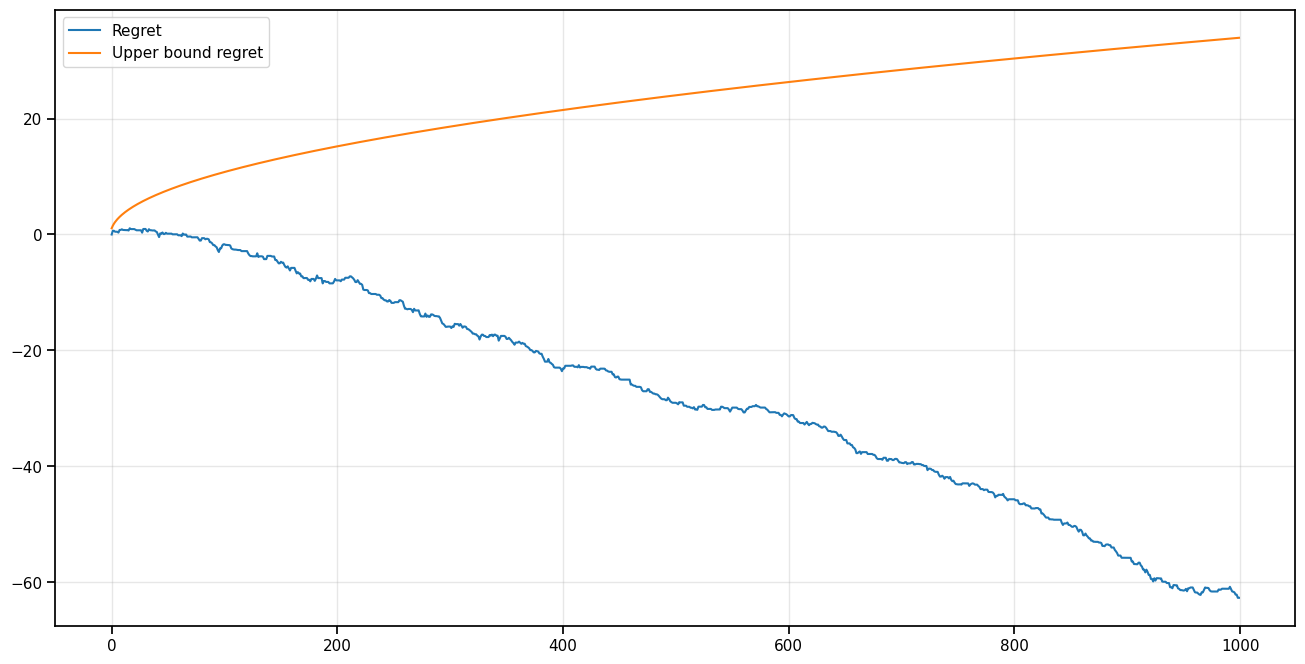

In [37]:
"""
построим  график реализованного и теоретического регретов

необходимые значения можно получить из результатов res
"""
L_hat_t = jnp.cumsum(res['step-loss-forecaster'])
L_exp_t = jnp.cumsum(res['step-loss-experts'], axis=0)   
regret_forecaster = L_hat_t - jnp.min(L_exp_t, axis=1)

t = jnp.arange(1, n_timesteps+1)
regret_ubound = jnp.log(n_experts) / params + (params / 8.0) * t

plt.plot(regret_forecaster, label="Regret")
plt.plot(regret_ubound, label="Upper bound regret")
plt.legend()
plt.grid(alpha=0.3)

2. Online Portfolio Selection

# 2.1

На семинаре мы рассматривали постановку OCO (Online Convex Optimization) применительно к онлайн выбору портфеля акций. Мы рассмотрели простой алгоритм Follow The **Linearized** Leader + два алгоритма в стратегии Follow The **Regularized** Leader:  [Exponentiated Gradient](http://www.rob.schapire.net/papers/HelmboldScSiWa98.pdf) и  [AdaHedge](https://arxiv.org/pdf/1912.13213) (7.6), в которых в качестве регуляризатора выступала **энтропия Шеннона** : $R(x) = \sum_{j=1}^{n} x_j log(x_j)$


Но могут быть и другие регуляризаторы, которые порождают другие алгоритмы. Например, **log-barier**: $R(x) = \sum_{j=1}^{n} log(<x, e_j>)$, где $(e_i)_{i=1}^n$ - базис. И задача принимает вид: $$x_t = argmax _{x\in \Delta_n} \sum_{t+1}^{t-1} log(<r_t, x>) + \sum_{j=1}^{n} log(<x, e_j>)$$

Если выбор портфеля происходит по формуле выше, то такая стратегия назвается **Smooth Selection**.

Но если в лоб решать эту задачу (назовем алгоритм **ss**), то регрет будет содержать в себе $r$, где $r$ нижняя граница всех регретов, т.е мы подразумеваем, что:
$1\geq r_t[i]\geq r > 0$.

Чтобы оценка регрета не содержала $r$ можно предложить модификацию алгоритма (назовем  **modified_ss**) с заменой, как в семинаре:
$$\tilde{r}_t ← (1-\frac{\alpha}{n})r_t + \frac{\alpha}{n} 1$$

$$\tilde{x}_t = (1-\alpha)x_t + \frac{\alpha}{n}$$

Cобственно, эти два алгоритма (ss + modified_ss) нужно реализвовать, и проверить их работу на синтетических и реальных ланный с yahoo. Части, которые повторяются с семинара уже используются, но в ноутбук семинара полезно заглянуть, чтобы понять как реализвать функции.

In [8]:
import cvxpy as cp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#!pip install yfinance
import yfinance as yf
import pandas as pd
import string
import random

sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (16, 8)

In [9]:
"""выбрать лучший портфель в терминах OCO 'заглядывая в будущее'

   с семинара - здесь ничего менять не нужно
"""
def Best_Constantly_Rebalanced_Portfolio(r):
  T = r.shape[0]
  n = r.shape[1]
  if T==0:
    return np.ones(n)/n

  x = cp.Variable(n)

  obj = cp.sum(cp.log(r@x))
  prob = cp.Problem(cp.Maximize(obj), [cp.sum(x) == 1, x >= 0])
  prob.solve()
  return x.value

 $$x_t = argmax _{x\in \Delta_n} \sum_{t=1}^{t-1} log(<r_t, x>) + \sum_{j=1}^{n} log(<x, e_j>)$$


 **Smooth_Selection** выдает вектор решений на каждом шаге, можете написать либо свою функцию. Либо интереснее подумать, как можно написать с помощью ранее определенной Best_Constantly_Rebalanced_Portfolio

---

Заметим что
 $$\sum_{j=1}^{n} \log(\langle x, e_j \rangle) = \log\left(\prod_{j=1}^{n} \langle x, e_j \rangle\right)$$

$$\sum_{t=1}^{t-1} \log(\langle r_t, x \rangle) = \log\left(\prod_{t=1}^{t-1} \langle r_t, x \rangle\right)$$

 $$\implies$$

  $$x_t = \arg\max_{x \in \Delta_n} \log\left(\prod_{t=1}^{t-1} \langle r_t, x \rangle \cdot \prod_{j=1}^{n} \langle x, e_j \rangle\right)$$

 Let $R \in \mathbb{R}^{(t-1) \times n}$ be the matrix of returns and $I_n \in \mathbb{R}^{n \times n}$ be the identity matrix.
 
 Define the augmented matrix $\tilde{R} = \begin{pmatrix} R \\ I_n \end{pmatrix} \in \mathbb{R}^{(t-1+n) \times n}$
 
   $$x_t = \arg\max_{x \in \Delta_n} \sum_{i=1}^{t-1+n} \log(\tilde{R}_i x) = \text{Best\_CRP}(\tilde{R})$$

In [60]:
# Smooth_Selection на вход принимает r - вектор регретов, выдает вектор портфеля x до рассматриваемого шага t
# можно и нужно использовать ранее определенную Best_Constantly_Rebalanced_Portfolio (посмотри в семинаре)
from tqdm import tqdm

def Smooth_Selection(r):
  T = r.shape[0]
  n = r.shape[1]
  x = np.zeros((T,n))
  for t in tqdm(range(T), desc="Smooth Selection"):
    x[t] = Best_Constantly_Rebalanced_Portfolio(np.vstack([r[:t], np.eye(n)]))
  return x

  с модификацией мы должны решать задачу:
  $$x_t = \arg\max_{x \in \Delta_n} \sum_{\tau=1}^{t-1} \log(\langle \tilde{r}_\tau, x \rangle) + \varepsilon \cdot \sum_{j=1}^{n} \log(\langle \tilde{x}, e_j \rangle)$$
  
  подставляя:
  
  $$\tilde{r}_t \leftarrow \left(1-\frac{\alpha}{n}\right)r_t + \frac{\alpha}{n} \mathbf{1}$$
  
  $$\tilde{x}_t = (1-\alpha)x_t + \frac{\alpha}{n}$$
  
  $$\varepsilon = \frac{1}{r_{min}}$$
  
  $$\alpha = n \sqrt{\frac{\log T}{T}}$$


In [61]:
def Modified_Smooth_Selection(r):
  T = r.shape[0]
  n = r.shape[1]
  x = np.zeros((T,n))
  x_tilde = np.zeros((T,n))
  alpha = n * np.sqrt(np.log(T) / T)
  eps = 1 / r.min()
  r_tilde = (1 - alpha/n) * r + alpha/n
  for t in tqdm(range(T), desc="Modified Smooth Selection"):
    x[t] = Best_Constantly_Rebalanced_Portfolio(
      np.vstack([
        r_tilde[:t],
        eps *  np.eye(n, n)
      ])
    )
    x_tilde[t] = (1 - alpha) * x[t] + alpha/n
  return x_tilde

ПРОВЕРКА РАБОТЫ НА СИНТЕТИКЕ

In [22]:
random.seed(444)
np.random.seed(444)
# число стоков(акций)
n = 5
# генерим названия стоков
dummy_stocks = [''.join(random.choices(string.ascii_uppercase, k=5)) for i in range(n)]
# рассматриваемый период
T = 700

#Log-normal returns
r = np.exp(np.random.normal(0, 0.03, size=(T,n)))
df = pd.DataFrame(data = r.cumprod(axis=0), columns = dummy_stocks)

<Axes: >

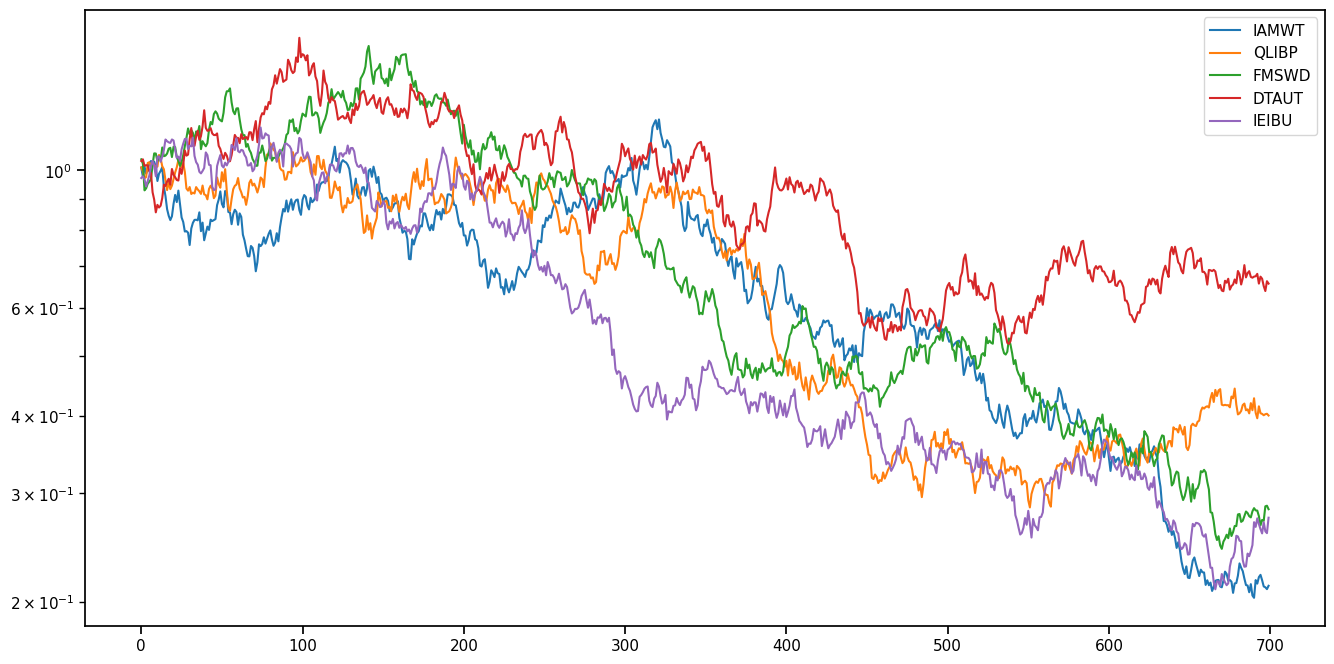

In [23]:
df.plot(logy=True)

In [ ]:
bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df['BCRP']= np.cumprod(r@bcrp)

smooth = Smooth_Selection(r)
df['Smooth'] = np.cumprod(np.sum(r*smooth, axis=1))

modified = Modified_Smooth_Selection(r)
df['Modified Smooth'] = np.cumprod(np.sum(r*modified, axis=1))

<Axes: >

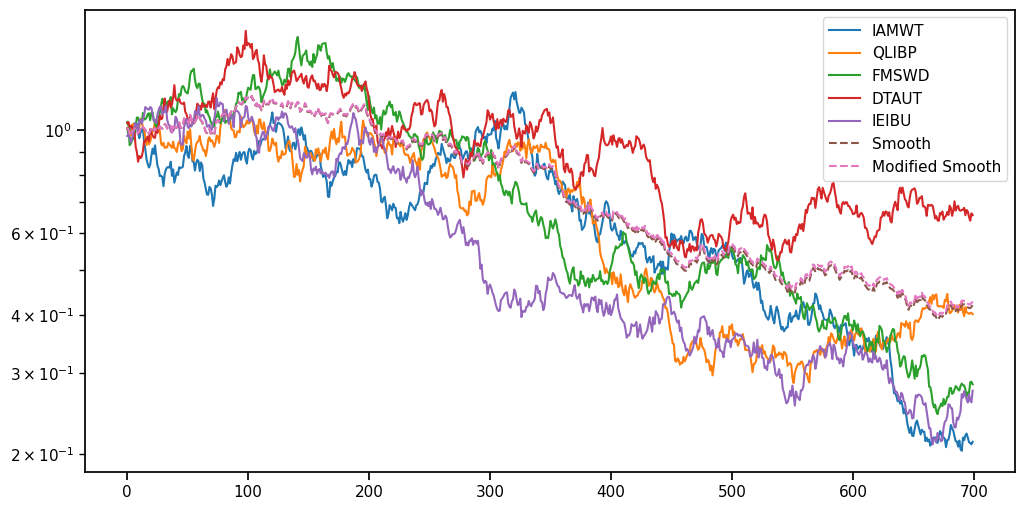

In [27]:
#cмотрим как ведут себя стратегии smooth и modified smooth по отношению к траекториям отдельных акций

ax = df[dummy_stocks].plot(logy=True, figsize=(12, 6))
df[['Smooth', 'Modified Smooth']].plot(ax=ax, logy=True, style='--')

<Axes: >

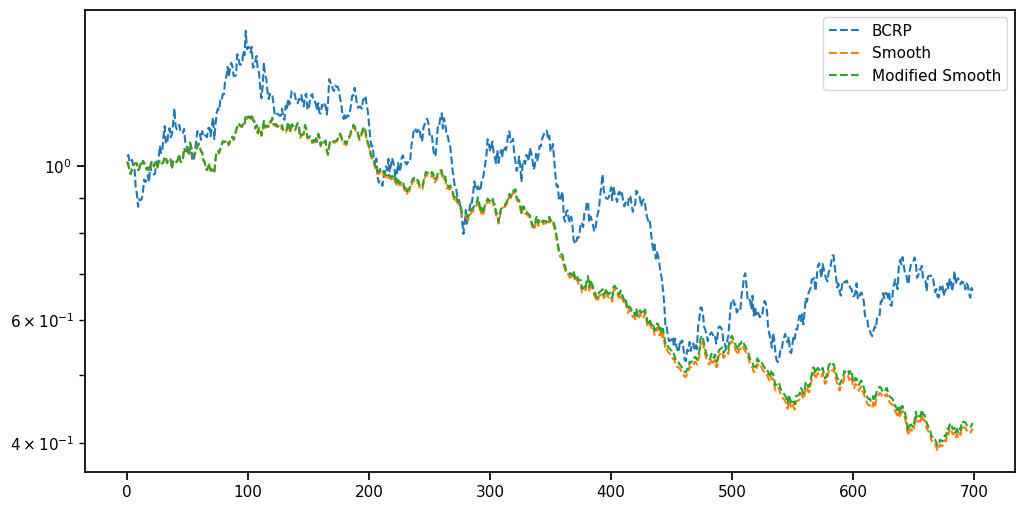

In [29]:
#cмотрим как ведут себя стратегии smooth и modified smooth по отношению к лучшей (в терминах OCO) стратегии

df[['BCRP', 'Smooth', 'Modified Smooth']].plot(logy=True, figsize=(12, 6), style='--')

ПРОВЕРКА РАБОТЫ НА РЕАЛЬНЫХ ДАННЫХ

In [31]:
# выбор рассматриваемого периода
start = '2020-01-01'
end = '2025-12-31'

# выбор стоков
assets = [ 'JPM', 'NFLX', 'XOM', 'VZ', 'META']
assets.sort()
n = len(assets)


# загрузка данных
data = yf.download(assets, start = start, end = end)
data = data.loc[:,('Close', slice(None))]
data.columns = assets

# вычислениу r

df = 1+data[assets].pct_change().dropna()/100
r = df.to_numpy()
df = df.cumprod(axis=0)

[*********************100%***********************]  5 of 5 completed


<Axes: xlabel='Date'>

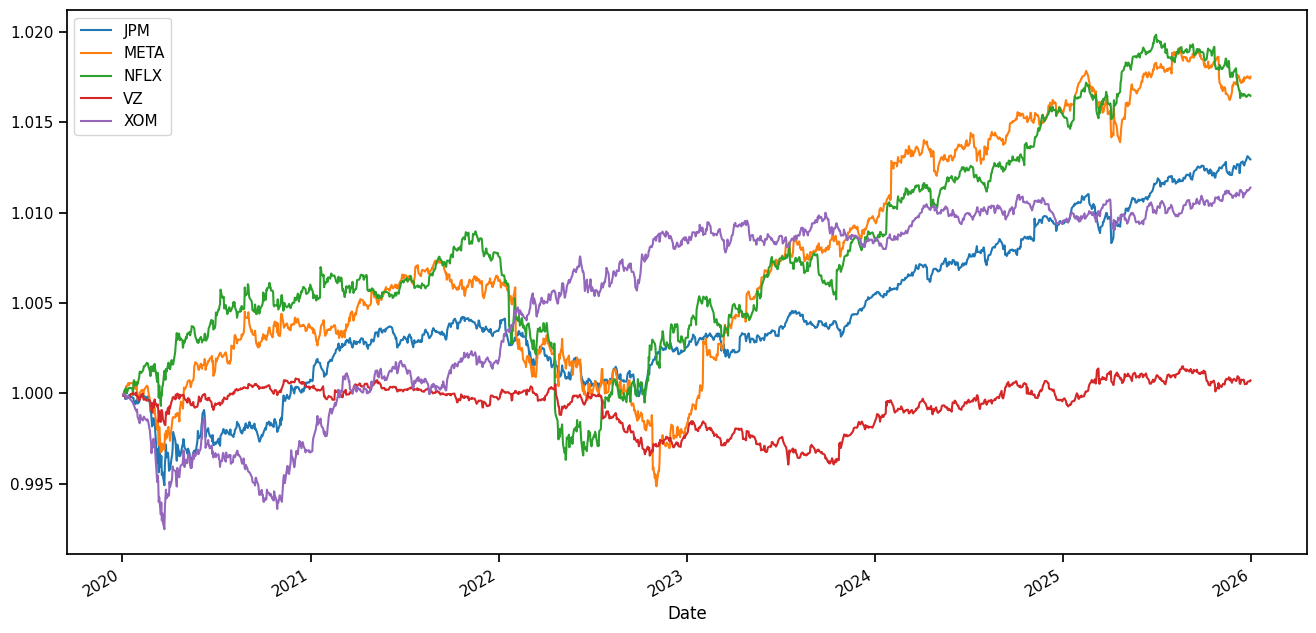

In [32]:
#cмотрим на траектории отдельных акций
df.plot()

/var/folders/w_/272kwk3n4m1df8dcsy63zpbm0000gn/T/ipykernel_63507/2321443718.py:15: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve()


<Axes: xlabel='Date'>

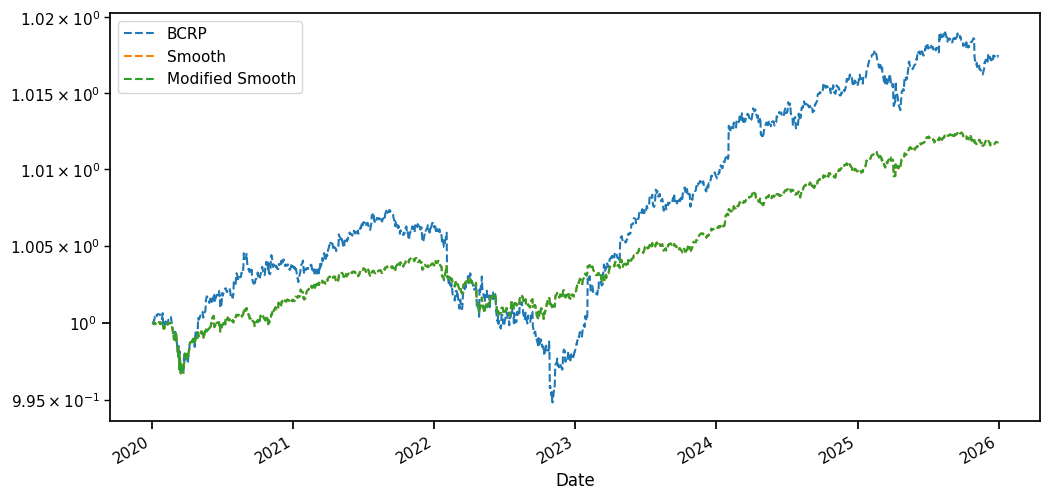

In [34]:
#cмотрим как ведут себя стратегии smooth и modified smooth по отношению к лучшей (в терминах OCO) стратегии

bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df['BCRP']= np.cumprod(r@bcrp)

smooth = Smooth_Selection(r)
df['Smooth'] = np.cumprod(np.sum(r*smooth, axis=1))

modified = Modified_Smooth_Selection(r)
df['Modified Smooth'] = np.cumprod(np.sum(r*modified, axis=1))

df[['BCRP', 'Smooth', 'Modified Smooth']].plot(logy=True, figsize=(12, 6), style='--')

#2.2

В семинаре, в стратегии Linearized Follow-The--Leader, мы использовали линейную аппроксимацию:
**Linearizing** $$f_t(x) \sim f_t(x_t) + \nabla f_t(x_t)^T(x-x_t)$$

**А что если рассмотрим точность до второго порядка? -> т.е метод Ньютона.**
$$f_t(x) \sim f_t(x_t) + \nabla f_t(x_t)^T(x-x_t) + \frac{1}{2} (x-x_t)^TA_t(x_t)(x-x_t)$$

 Здесь: $$A_t(x) = \frac{r_t r_t^T}{(r_t^T x)^2}$$
**Ну и выбор портфеля делаем:** $$x_{t+1} = argmin_{x\in \Delta_n} \sum_{t=1}^t f_t(x)$$

Тогда стратегия называется **Quadratized Follow-The-Leader**

Ну еще регуляризатор добавим: $$x_{t+1} = argmin_{x\in \Delta_n} \sum_{t=1}^t f_t(x) + \varepsilon R(x)$$ и получим **Quadratized Follow-The-Regularized-Leader**)).

 Здесь $\varepsilon$, чтобы общий случай рассмотреть: 0, если не учитываем регуляризатор и, например, 1, если учитываем.

Рассмотрим **регуляризатор** для квадратичных функций: $R(x) = \frac{1}{2} ||x||_2^2$

In [68]:
import numpy as np
import cvxpy as cp

def Quadratized_Follow_The_Regularized_Leader(r, epsilon, delta=1e-12):
    T, n = r.shape
    x = np.zeros((T, n))
    if T == 0:
        return x
    if epsilon < 0:
        raise ValueError("epsilon must be >= 0")

    x[0] = np.ones(n) / n

    H = np.zeros((n, n))
    b = np.zeros(n)
    I = np.eye(n)

    for t in tqdm(range(1, T), desc="QFTRL"):
        s = t - 1
        r_s = r[s]
        x_s = x[s]

        denom = max(r_s @ x_s, delta)
        g_s = -r_s / denom
        A_s = np.outer(r_s, r_s) / (denom ** 2)

        H += A_s
        b += g_s - A_s @ x_s

        P = 0.5 * ((H + epsilon * I) + (H + epsilon * I).T)

        x_var = cp.Variable(n)
        obj = 0.5 * cp.quad_form(x_var, P) + b @ x_var
        constraints = [cp.sum(x_var) == 1, x_var >= 0]
        prob = cp.Problem(cp.Minimize(obj), constraints)

        prob.solve(solver=cp.OSQP, verbose=False)
        if x_var.value is None:
            raise RuntimeError("Solver failed to produce a solution")

        x[t] = x_var.value

    return x

СИНТЕТИКА

In [69]:
random.seed(444)
np.random.seed(444)
# число стоков(акций)
n = 5
# генерим названия стоков
dummy_stocks = [''.join(random.choices(string.ascii_uppercase, k=5)) for i in range(n)]
# рассматриваемый период
T = 700

#Log-normal returns
r = np.exp(np.random.normal(0, 0.03, size=(T,n)))
df = pd.DataFrame(data = r.cumprod(axis=0), columns = dummy_stocks)

QFTRL: 100%|██████████| 699/699 [00:01<00:00, 396.48it/s]


<Axes: >

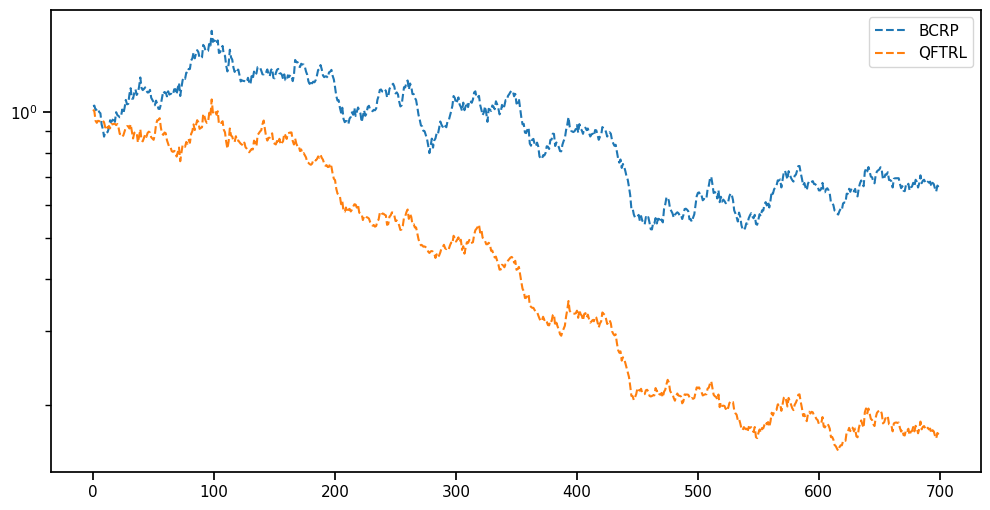

In [70]:
epsilon = 0.1

x_qftrl = Quadratized_Follow_The_Regularized_Leader(r, epsilon)
df['QFTRL'] = np.cumprod(np.sum(x_qftrl * r, axis=1))

bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df['BCRP']= np.cumprod(r@bcrp)

df[['BCRP', 'QFTRL']].plot(logy=True, figsize=(12, 6), style='--')

ПРОВЕРКА РАБОТЫ НА РЕАЛЬНЫХ ДАННЫХ

In [66]:
# выбор рассматриваемого периода
start = '2020-01-01'
end = '2025-12-31'

# выбор стоков
assets = [ 'JPM', 'NFLX', 'XOM', 'VZ', 'META']
assets.sort()
n = len(assets)


# загрузка данных
data = yf.download(assets, start = start, end = end)
data = data.loc[:,('Close', slice(None))]
data.columns = assets

# вычислениу r

df = 1+data[assets].pct_change().dropna()/100
r = df.to_numpy()
df = df.cumprod(axis=0)

[*********************100%***********************]  5 of 5 completed


Smooth Selection:  12%|█▏        | 188/1506 [00:00<00:04, 267.75it/s]/var/folders/w_/272kwk3n4m1df8dcsy63zpbm0000gn/T/ipykernel_63507/2321443718.py:15: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve()
QFTRL:   0%|          | 0/1505 [00:00<?, ?it/s]/var/folders/w_/272kwk3n4m1df8dcsy63zpbm0000gn/T/ipykernel_63507/3107848027.py:42: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)
QFTRL: 100%|██████████| 1505/1505 [00:03<00:00, 434.50it/s]


<Axes: xlabel='Date'>

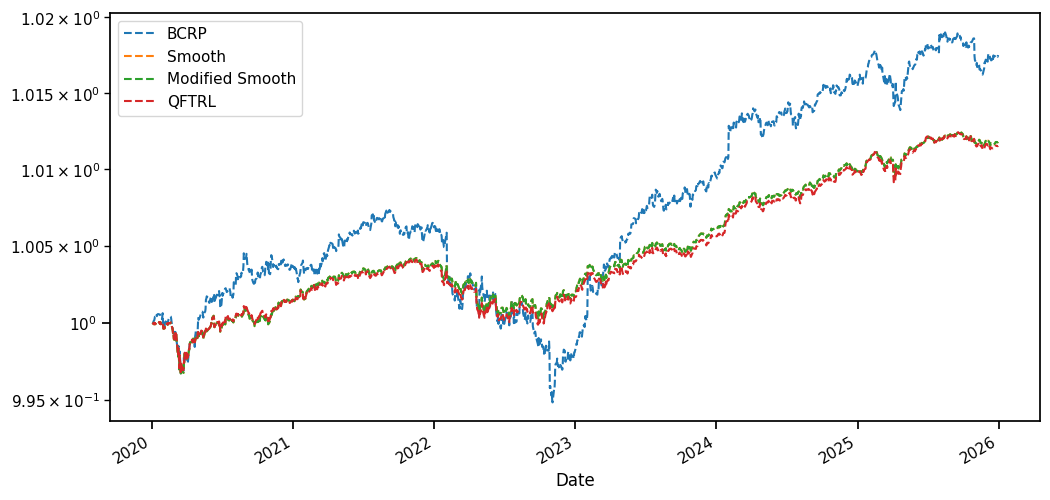

In [67]:
#cмотрим как ведут себя все раннее написанные стратегии на реальных данных  по отношению к лучшей (в терминах OCO) стратегии на синтетике

bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df['BCRP']= np.cumprod(r@bcrp)

smooth = Smooth_Selection(r)
df['Smooth'] = np.cumprod(np.sum(r*smooth, axis=1))

modified = Modified_Smooth_Selection(r)
df['Modified Smooth'] = np.cumprod(np.sum(r*modified, axis=1))

x_qftrl = Quadratized_Follow_The_Regularized_Leader(r, epsilon)
df['QFTRL'] = np.cumprod(np.sum(x_qftrl * r, axis=1))

df[['BCRP', 'Smooth', 'Modified Smooth', 'QFTRL']].plot(logy=True, figsize=(12, 6), style='--')